# Crates.io Dependency Network Community Detection

## 社区结构与功能模块

利用社区发现算法（如 Louvain 或 Leiden）来对网络进行无监督分区。

*   **发现领域集群**：看看社区是否自然形成了“前端渲染”、“网络请求”、“命令行工具”、“游戏开发”、“嵌入式”等板块。
*   **交叉验证**：可以爬取crate的分类信息（如 `categories` 字段），看社区发现的划分与人工标签是否一致。不一致的地方往往隐藏着有趣的多面手crate或误分类情况。
*   **桥梁分析**：找出连接不同社区的**边界节点**，它们往往是最具创新性的crate，但也是风险交叉传染的通道。


In [1]:
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
import json

from utils import largest_component_graph, write_json

from enum import Enum
class Snapshot(Enum):
    SNAPSHOT_2018_09_26 = "2018-09-26"
    SNAPSHOT_2020_11_20 = "2020-11-20"
    SNAPSHOT_2022_07_06 = "2022-07-06"
    SNAPSHOT_2024_03_11 = "2024-03-11"
    SNAPSHOT_2026_05_25 = "2026-05-25"

## Configuration

In [2]:
from dataclasses import dataclass
date = Snapshot.SNAPSHOT_2024_03_11.value
root_dir = Path(f"outputs_{date}")
@dataclass
class AnalysisConfig:
    edges: Path
    nodes: Path
    out_dir: Path = root_dir / "analysis"
    path_samples: int = 50
    top_k: int = 30
    seed: int = 7
    skip_powerlaw: bool = False
    skip_community: bool = False
    skip_pagerank: bool = False

args = AnalysisConfig(
    edges=root_dir / "core_edges.csv",
    nodes=root_dir / "core_nodes.csv",
    out_dir=root_dir / "analysis",
    top_k=60,
)

out_dir = args.out_dir
out_dir.mkdir(parents=True, exist_ok=True)

In [3]:
graph = nx.DiGraph()
graph = nx.read_gml(out_dir.parent / "core_graph.gml")
undirected = graph.to_undirected()
undirected = largest_component_graph(undirected)

In [4]:
print("Community detection")
communities: list[set[str]] = list(
    nx.algorithms.community.louvain_communities(undirected, seed=args.seed)
)

print(len(communities), communities[0])

Community detection
71 {'storylets', 'bed2gff', 'cargo-pipe', 'nb2nl', 'tivilsta', 'fwdt', 'html_editor', 'timepiece', 'tengwar', 'cplat', 'mirrorshine', 'minimap', 'distant', 'postform_serial', 'fluxer', 'efron_numbertheory', 'claw', 'remediate', 'pciids', 'tomq', 'smartpool-spatial', 'dirhash', 'uggo', 'playdate-build', 'kryptos', 'deadnix', 'dottler', 'csv-merger', 'qsv2flv', 'datadot', 'ahqstore_cli_rs', 'ucli', 'pimalaya-email-tpl', 'tcplscan', 'bionic-ebooks', 'smartcat', 'copo', 'ngxav', 'liquid-layout', 'rrcm', 'trigout', 'cargo-ghp-upload', 'time-condition', 'csv_log_cleaner', 'pandoc-filter-diagram', 'clock-tui', 'ru_shell', 'petersn-qdcache', 'grav1synth', 'perbase', 'rename-extensions', 'rquickjs-core', 'smhkd', 'rustop-rs', 's3lsio', 'smafa', 'queue', 'sss_moo', 'trello-rs', 'cargo-docco', 'test-fuzz-internal', 'thumbnailer-bridge', 'rammer', 'mapwords', 'peeking_take_while', 'pipe-logger', 'multisol', 'recurse', 'anticipate-cli', 'token_trekker_rs', 'kwiwk-experimental', 

In [5]:
sorted_communities = sorted(communities, key=len, reverse=True)
print(len(sorted_communities[0]), sorted_communities[0])
sizes = sorted((len(comm) for comm in communities), reverse=True)
modularity = None
if communities:
    modularity = float(nx.algorithms.community.quality.modularity(undirected, communities))

summary = {
    "algorithm": "louvain_communities",
    "communities": len(communities),
    "top_sizes": sizes[:20],
    "modularity": modularity,
}
write_json(out_dir / "community_summary.json", summary)


22192 {'explain', 'ferinth', 'jsonptr', 'try-lock', 'disaronno-macros', 'chromiumoxide', 'covet', 'kenku_control', 'antidote', 'ippper', 'hutools', 'mure', 'huawei-cloud-api-definitions-CGS', 'covert-types', 'ndjson-stream', 'tel', 'headers', 'aws-iam', 'google-accesscontextmanager1-cli', 'mammoth-setup', 'aoc-next', 'openai_gpt_rs', 'build-plan', 'sanitise-file-name', 'elipdotter', 'flagsmith-async', 'google-cloudtrace1', 'dropshot', 'lexi-rs', 'enchant-sys', 'google-dialogflow2-cli', 'noiseless-tracing-actix-web', 'skyway-webrtc-gateway-caller', 'netdia-cli', 'isolanguage-1', 'happy', 'async-pipeline', 'maia-json', 'derive-getters', 'loadem', 'kyoto_network', 'google-kgsearch1', 'tokkit', 'kvarn-fastcgi-client', 'oplog', 'rayon_logs', 'wiser', 'imgur_rs', 'nedis', 'scm-cli', 'adns-client', 'bird-protocol-server', 'leanpub-cli', 'dev-scope', 'dango', 'zigbee2mqtt_types_vendor_moes', 'netsblox-cloud', 'final-state-rs', 'message_worker', 'netloc-http-request', 'fumnet', 'libp2prs-traits

In [ ]:
# For Windows users, you can use the following PowerShell command to download the file:
!Start-BitsTransfer -Source "https://static.crates.io/db-dump.tar.gz" -Destination "f:\db-dump.tar.gz"
!tar -xzvf "f:\db-dump.tar.gz" -C "f:\db-dump"

# For Linux/Mac users, you can use the following command in the terminal:
# !wget -O db-dump.tar.gz https://static.crates.io/db-dump.tar.gz
# !tar -xzvf db-dump.tar.gz -C db-dump

In [6]:
db_dump_dir = Path(r"f:\db-dump\2026-05-26-020032")
labels_path = out_dir / "crate_labels.csv"
!cargo run -q --release --bin extract_labels -- --db-dir "{db_dump_dir}" --out "{labels_path}"

Output: outputs_2024-03-11\analysis\crate_labels.csv
Crates: 273391
Crates with categories: 118671
Crates with keywords: 150936


In [7]:
from collections import defaultdict
from tqdm.auto import tqdm

community_map = {}
for idx, comm in enumerate(communities):
    for node in comm:
        community_map[node] = idx

cross_counts: dict[str, int] = defaultdict(int)
neighbor_comm_counts: dict[str, dict[int, int]] = defaultdict(lambda: defaultdict(int))

for u, v in tqdm(undirected.edges(), desc="Counting community edges", unit="edges"):
    cu = community_map.get(u)
    cv = community_map.get(v)
    if cu is None or cv is None:
        continue
    neighbor_comm_counts[u][cv] += 1
    neighbor_comm_counts[v][cu] += 1
    if cu != cv:
        cross_counts[u] += 1
        cross_counts[v] += 1

participation: dict[str, float] = {}
for node, counts in neighbor_comm_counts.items():
    k = sum(counts.values())
    if k == 0:
        participation[node] = 0.0
    else:
        participation[node] = 1.0 - sum((c / k) ** 2 for c in counts.values())

min_degree = 10
top_cross = sorted(cross_counts.items(), key=lambda x: x[1], reverse=True)[:20]
top_part = sorted(
    ((n, p) for n, p in participation.items() if undirected.degree(n) >= min_degree),
    key=lambda x: x[1],
    reverse=True,
 )[:20]

print("Top cross-community nodes:")
for rank, (name, count) in enumerate(top_cross, start=1):
    deg = undirected.degree(name)
    part = participation.get(name, 0.0)
    print(rank, name, count, f"deg={deg}", f"P={part:.3f}")

print(f"Top participation coefficient (degree >= {min_degree}):")
for rank, (name, score) in enumerate(top_part, start=1):
    deg = undirected.degree(name)
    cross = cross_counts.get(name, 0)
    print(rank, name, f"P={score:.3f}", f"deg={deg}", f"cross={cross}")

e:\Documents\learnRust\dependencies-network\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Counting community edges: 100%|██████████| 606343/606343 [00:01<00:00, 465530.29edges/s]


Top cross-community nodes:
1 serde 14600 deg=29153 P=0.720
2 log 13196 deg=15104 P=0.865
3 thiserror 11697 deg=13874 P=0.855
4 clap 7798 deg=13419 P=0.734
5 serde_json 7793 deg=19474 P=0.619
6 anyhow 6407 deg=11201 P=0.763
7 rand 5825 deg=8821 P=0.813
8 lazy_static 5147 deg=7292 P=0.840
9 regex 4323 deg=7435 P=0.755
10 chrono 3847 deg=8358 P=0.671
11 tokio 3561 deg=11975 P=0.497
12 once_cell 3400 deg=4361 P=0.869
13 futures 3386 deg=8370 P=0.629
14 itertools 3020 deg=4622 P=0.822
15 tracing 2519 deg=5488 P=0.686
16 base64 2503 deg=3581 P=0.747
17 env_logger 2458 deg=3553 P=0.799
18 libc 2422 deg=5627 P=0.649
19 bytes 2215 deg=4971 P=0.660
20 num-traits 2173 deg=3291 P=0.817
Top participation coefficient (degree >= 10):
1 either P=0.897 deg=641 cross=530
2 ipmb P=0.888 deg=14 cross=12
3 stackdump-trace P=0.888 deg=13 cross=11
4 relearn P=0.885 deg=23 cross=20
5 ibtwsapi P=0.884 deg=21 cross=17
6 static_assertions P=0.884 deg=467 cross=359
7 hippotat P=0.884 deg=34 cross=30
8 super-proce

In [8]:
def load_json(path: Path):
    if not path.exists():
        print(f"Missing: {path}")
        return None
    with path.open(encoding="utf-8") as handle:
        return json.load(handle)
community_summary = load_json(out_dir / "community_summary.json")


Community summary:
{
  "algorithm": "louvain_communities",
  "communities": 71,
  "top_sizes": [
    22192,
    17464,
    12967,
    9589,
    9148,
    7746,
    4401,
    4315,
    3361,
    3059,
    2467,
    2265,
    1638,
    1514,
    1413,
    1024,
    487,
    410,
    358,
    258
  ],
  "modularity": 0.4496573610070166
}


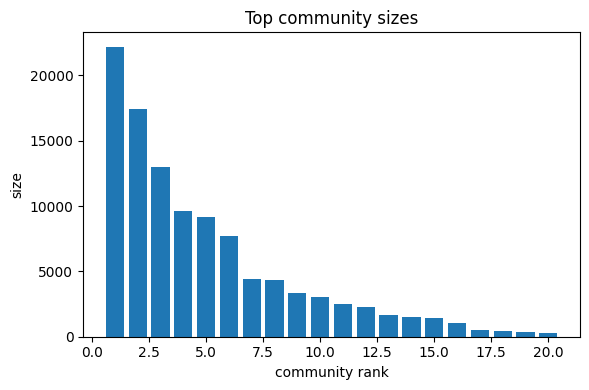

In [9]:
if community_summary:
    if community_summary.get("skipped"):
        print("Community detection skipped:", community_summary.get("reason"))
    else:
        print("Community summary:")
        print(json.dumps(community_summary, indent=2))
        sizes = community_summary.get("top_sizes", [])
        if sizes:
            plt.figure(figsize=(6, 4))
            plt.bar(range(1, len(sizes) + 1), sizes)
            plt.title("Top community sizes")
            plt.xlabel("community rank")
            plt.ylabel("size")
            plt.tight_layout()
            plt.show()

In [10]:
import csv
from collections import Counter



if not labels_path.exists():
    print("Generate labels with Rust:")
    print(f"cargo run --release --bin extract_labels -- --db-dir \"{db_dump_dir}\" --out \"{labels_path}\"")
else:
    def load_labels(path: Path) -> dict[str, dict[str, list[str]]]:
        labels = {}
        with path.open(newline="", encoding="utf-8") as handle:
            reader = csv.DictReader(handle)
            for row in reader:
                name = row.get("crate")
                if not name:
                    continue
                categories = [c for c in row.get("categories", "").split(";") if c]
                keywords = [k for k in row.get("keywords", "").split(";") if k]
                labels[name] = {"categories": categories, "keywords": keywords}
        return labels

    labels = load_labels(labels_path)

    def summarize_labels(
            comm: set[str], 
            labels: dict[str, dict[str, list[str]]], 
            key: str, 
            top_k: int = 5
        ) -> tuple[int, float, list[tuple[str, int]]]:
        counts = Counter()
        labeled_nodes = 0
        for node in comm:
            items = labels.get(node, {}).get(key, [])
            if items:
                labeled_nodes += 1
                counts.update(set(items))
        top: list[tuple[str, int]] = counts.most_common(top_k)
        purity = (top[0][1] / labeled_nodes) if labeled_nodes and top else 0.0
        return labeled_nodes, purity, top

    top_comm = sorted(communities, key=len, reverse=True)[:10]
    total_labeled = 0
    weighted_purity = 0.0

    print("Top community label summaries (categories):")
    for idx, comm in enumerate(top_comm, start=1):
        labeled, purity, top = summarize_labels(comm, labels, "categories")
        size = len(comm)
        if labeled:
            weighted_purity += purity * labeled
            total_labeled += labeled
        top_str = ", ".join([f"{name}({count})" for name, count in top])
        print(f"#{idx} size={size} labeled={labeled} purity={purity:.3f} top={top_str}")

    if total_labeled:
        print(f"Weighted purity (categories): {weighted_purity / total_labeled:.3f}")

    print("Top community label summaries (keywords):")
    for idx, comm in enumerate(top_comm, start=1):
        labeled, purity, top = summarize_labels(comm, labels, "keywords")
        size = len(comm)
        top_str = ", ".join([f"{name}({count})" for name, count in top])
        print(f"#{idx} size={size} labeled={labeled} purity={purity:.3f} top={top_str}")

Top community label summaries (categories):
#1 size=22192 labeled=7751 purity=0.222 top=Command line utilities(1717), API bindings(1306), Network programming(1302), Asynchronous(1298), Web programming(1017)
#2 size=17464 labeled=7475 purity=0.476 top=Command line utilities(3555), Development tools(871), Command-line interface(665), Text processing(601), Parsing tools(408)
#3 size=12967 labeled=5694 purity=0.116 top=Science(660), Game development(655), Data structures(637), Graphics(570), GUI(568)
#4 size=9589 labeled=3236 purity=0.156 top=Rust patterns(505), No standard library(430), Development tools(407), Data structures(318), Web programming(241)
#5 size=9148 labeled=3489 purity=0.325 top=Cryptography(1133), No standard library(611), Command line utilities(503), Algorithms(359), Encoding(333)
#6 size=7746 labeled=3128 purity=0.217 top=API bindings(678), External FFI bindings(452), Network programming(311), Command line utilities(290), No standard library(269)
#7 size=4401 labeled=15

In [11]:
import wordcloud

out_dir = root_dir / "community"
out_dir.mkdir(parents=True, exist_ok=True)

def get_label_text(
        comm: set[str],
        labels: dict[str, dict[str, list[str]]],
        key: str
    ) -> Counter:
    text_counts = Counter()
    for node in comm:
        items = labels.get(node, {}).get(key, [])
        if items:
            text_counts.update(items)
    return text_counts

for idx, comm in enumerate(top_comm, start=1):
    wc = wordcloud.WordCloud(width=1000, height=600, background_color="white")
    wc.generate_from_frequencies(get_label_text(comm, labels, "categories"))
    wc.to_file(f"{out_dir}/{idx}-categories.png")

for idx, comm in enumerate(top_comm, start=1):
    wc = wordcloud.WordCloud(width=1000, height=600, background_color="white")
    wc.generate_from_frequencies(get_label_text(comm, labels, "keywords"))
    wc.to_file(f"{out_dir}/{idx}-keywords.png")

## Gephi 可视化导出

采用**分层度排序抽样**（stratified degree-based sampling）来高效生成 Gephi 可视化图：
1. 每个社区按其规模分配节点配额，总目标 ~15K 节点（Gephi 交互流畅的阈值）。
2. 社区内部按度数降序选取高影响力节点，保留网络骨架结构。
3. 提取诱导子图并保留最大连通分量。
4. 导出为 **GEXF** 格式（Gephi 原生格式，属性保留最佳），节点附带 `community` 和 `degree` 属性。

在 Gephi 中打开后：
- **布局** → ForceAtlas2（勾选 "Prevent Overlap"）
- **外观** → 节点颜色 → Partition → 选择 `community` 属性
- **外观** → 节点大小 → Ranking → 选择 `degree` 属性


In [15]:
import random
from collections import Counter, defaultdict

random.seed(args.seed)

# ── 1. Build community map ──────────────────────────────────
community_map: dict[str, int] = {}
community_members: dict[int, list[str]] = defaultdict(list)
for idx, comm in enumerate(communities):
    for node in comm:
        community_map[node] = idx
        community_members[idx].append(node)

# ── 2. Stratified degree-based sampling ─────────────────────
TARGET_NODES = 15_000
total_nodes = len(undirected)
sample_nodes: set[str] = set()

for comm_id, members in community_members.items():
    quota = max(3, int(TARGET_NODES * len(members) / total_nodes))
    quota = min(quota, len(members))
    # Sort by degree desc, pick top
    top_members = sorted(members, key=lambda n: undirected.degree(n), reverse=True)[:quota]
    sample_nodes.update(top_members)

print(f"Sampled {len(sample_nodes)} nodes from {len(communities)} communities")

# ── 3. Extract subgraph, keep largest component ──────────────
subgraph = undirected.subgraph(sample_nodes)
subgraph = largest_component_graph(subgraph)
print(f"Induced subgraph: {subgraph.number_of_nodes():,} nodes, {subgraph.number_of_edges():,} edges")

# ── 4. Annotate node attributes for Gephi ────────────────────
for node in subgraph.nodes():
    subgraph.nodes[node]['community'] = community_map.get(node, -1)
    subgraph.nodes[node]['degree'] = subgraph.degree(node)

# ── 5. Export GEXF ───────────────────────────────────────────
gexf_dir = root_dir / "community"
gexf_dir.mkdir(parents=True, exist_ok=True)
gexf_path = gexf_dir / "gephi_community.gexf"
nx.write_gexf(subgraph, str(gexf_path))
print(f"Exported → {gexf_path}")

# ── 6. Quick community stats of sample ───────────────────────
comm_counts = Counter(subgraph.nodes[n]['community'] for n in subgraph.nodes())
print(f"Communities in sample: {len(comm_counts)}, modularity: "
      f"{nx.algorithms.community.quality.modularity(subgraph, [set(c) for c in nx.algorithms.community.louvain_communities(subgraph, seed=args.seed)]):.4f}")

Sampled 15236 nodes from 148 communities
Induced subgraph: 15,135 nodes, 247,406 edges
Exported → outputs_2026-05-25\community\gephi_community.gexf
Communities in sample: 124, modularity: 0.3359
